## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
df = pd.read_csv('../data/data.csv')
df_original = df.copy()

In [3]:
np.random.seed(12)
df.sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
29735,42,Private,32981,HS-grad,9,Divorced,Machine-op-inspct,Not-in-family,White,Male,0,0,40,United-States,<=50K
38980,67,Private,212185,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,10,United-States,<=50K.
38016,39,Private,242922,HS-grad,9,Never-married,Tech-support,Not-in-family,Black,Male,0,0,35,United-States,<=50K.
24998,21,?,433330,Some-college,10,Never-married,?,Unmarried,White,Male,0,0,40,United-States,<=50K
21288,33,Private,146440,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,1740,40,United-States,<=50K


In [4]:
df.dtypes

age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object

## Handle Missing Values

In [5]:
df.isna().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

In [6]:
df = df.replace('?', np.nan)
df = df.replace(' ?', np.nan)

In [7]:
df.isnull().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

In [8]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent[missing_percent > 0].round(2)

workclass         5.73
occupation        5.75
native-country    1.75
dtype: float64

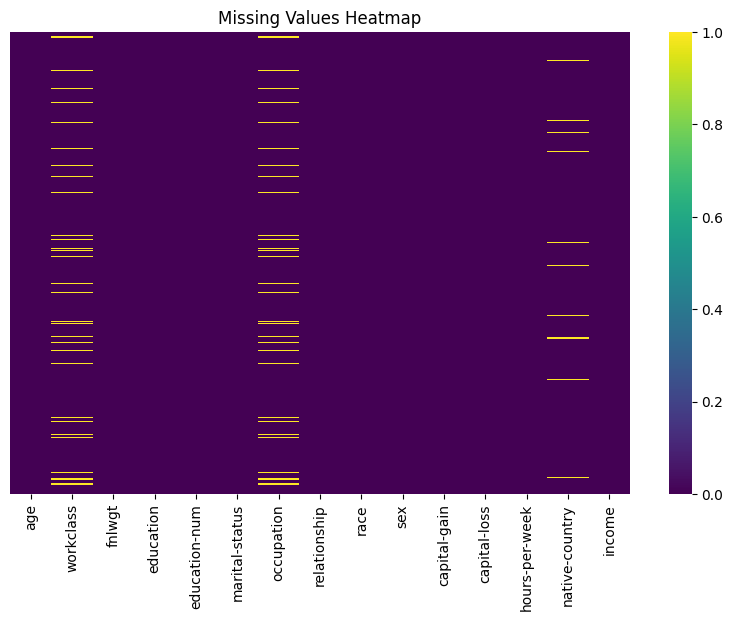

In [9]:
# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

In [10]:
df.dropna(inplace=True)

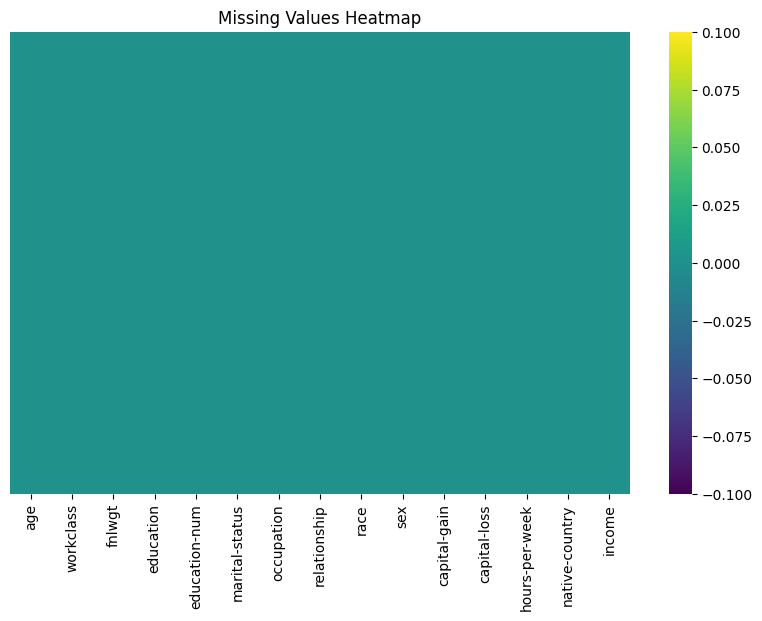

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

## Remove Duplicates

In [12]:
df.duplicated().sum()

np.int64(28)

In [13]:
df.drop_duplicates(inplace=True)

## Clean Text Data

In [14]:
categorical_cols = df.select_dtypes(include=['str']).columns
for col in categorical_cols:
    df[col] = df[col].str.strip()
    df[col] = df[col].str.rstrip('.')

In [15]:
df.sample(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
48026,35,State-gov,189794,HS-grad,9,Married-civ-spouse,Other-service,Wife,White,Female,0,0,40,United-States,<=50K
11270,25,Private,121102,Assoc-acdm,12,Never-married,Tech-support,Not-in-family,White,Female,0,2001,30,United-States,<=50K
45972,66,Self-emp-not-inc,51687,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,20,United-States,<=50K
26003,33,Private,341187,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States,>50K
18630,19,Private,552354,12th,8,Never-married,Machine-op-inspct,Own-child,White,Male,0,0,40,United-States,<=50K
36214,50,Private,260052,Bachelors,13,Divorced,Exec-managerial,Unmarried,White,Male,15020,0,40,United-States,>50K
16657,34,Self-emp-not-inc,319165,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,>50K
9636,24,Private,53942,Bachelors,13,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,<=50K
6109,41,Private,373469,Assoc-acdm,12,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,<=50K
19368,50,Self-emp-not-inc,163948,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,>50K


## Validate Data Ranges and Business Logic

In [16]:
# Age validation (reasonable adult working age)
invalid_age = df[(df['age'] < 17) | (df['age'] > 90)]
print(f"Invalid age records (< 17 or > 90): {len(invalid_age)}")

# Hours per week validation
invalid_hours = df[(df['hours-per-week'] < 1) | (df['hours-per-week'] > 100)]
print(f"Invalid hours-per-week records (< 1 or > 100): {len(invalid_hours)}")

# Capital gain/loss validation (should be non-negative)
invalid_capital = df[(df['capital-gain'] < 0) | (df['capital-loss'] < 0)]
print(f"Invalid capital records (negative values): {len(invalid_capital)}")

# Education number validation (reasonable range)
invalid_education = df[(df['education-num'] < 1) | (df['education-num'] > 16)]
print(f"Invalid education-num records (< 1 or > 16): {len(invalid_education)}")

Invalid age records (< 17 or > 90): 0
Invalid hours-per-week records (< 1 or > 100): 0
Invalid capital records (negative values): 0
Invalid education-num records (< 1 or > 16): 0


## Analyze and Handle Outliers

In [17]:
numerical_cols = df.select_dtypes(include=['int64']).columns.tolist()

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_percent = (len(outliers) / len(df)) * 100
    
    print(f"{col}: {len(outliers)} outliers ({outlier_percent:.2f}%)")

age: 268 outliers (0.59%)
fnlwgt: 1332 outliers (2.95%)
education-num: 291 outliers (0.64%)
capital-gain: 3790 outliers (8.39%)
capital-loss: 2140 outliers (4.74%)
hours-per-week: 11892 outliers (26.31%)


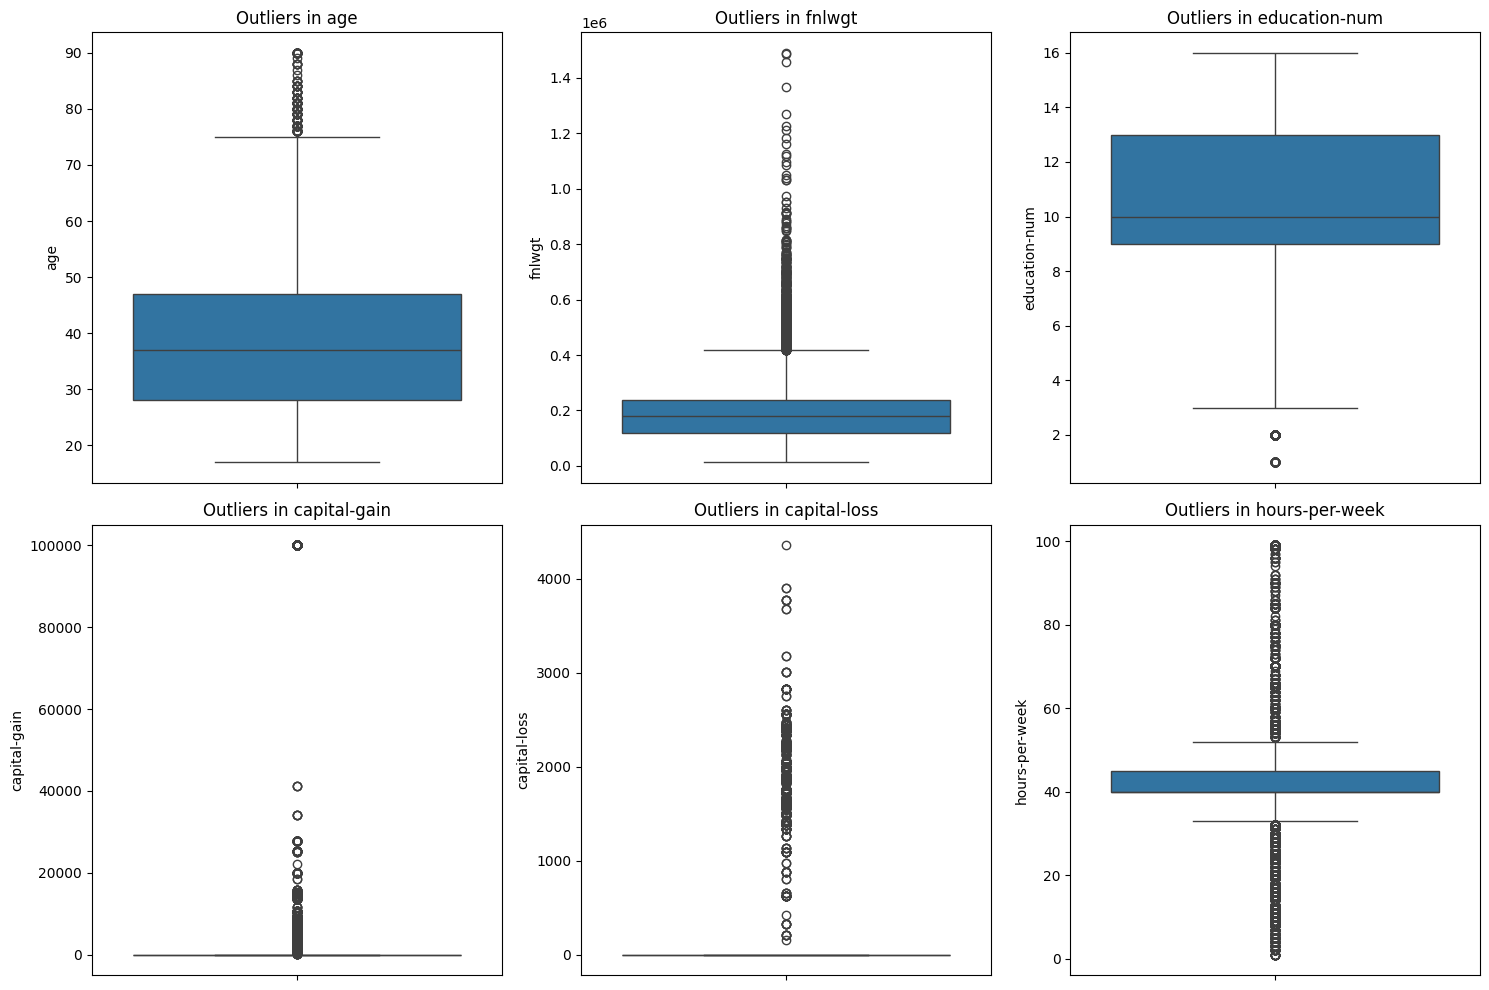

In [18]:
# Visualize outliers with boxplots
n_cols = len(numerical_cols)
n_rows = (n_cols + 2) // 3

plt.figure(figsize=(15, 5 * n_rows))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, 3, i + 1)
    sns.boxplot(data=df, y=col)
    plt.title(f'Outliers in {col}')
    plt.tight_layout()

plt.show()

## Reset Index and Final Validation

In [19]:
# Reset index for clean indexing
df = df.reset_index(drop=True)
print(f"Index reset. Final dataset shape: {df.shape}")

# Final validation
print("\nFINAL VALIDATION")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Data types: {df.dtypes.value_counts().to_dict()}")
print(f"Target variable classes: {df['income'].value_counts().to_dict()}")

Index reset. Final dataset shape: (45194, 15)

FINAL VALIDATION
Missing values: 0
Duplicate rows: 19
Data types: {<StringDtype(storage='python', na_value=nan)>: 9, dtype('int64'): 6}
Target variable classes: {'<=50K': 33988, '>50K': 11206}


## Save Cleaned Dataset

In [20]:
# Save cleaned dataset
df.to_csv('../data/data_cleaned.csv', index=False)
print("Cleaned dataset saved as 'data_cleaned.csv'")

# Summary report
print("\n" + "="*70)
print("DATA CLEANING REPORT")
print("="*70)
print(f"Original dataset size: {df_original.shape}")
print(f"Cleaned dataset size: {df.shape}")
print(f"Rows removed: {df_original.shape[0] - df.shape[0]} ({((df_original.shape[0] - df.shape[0])/df_original.shape[0])*100:.2f}%)")
print(f"Rows retained: {df.shape[0]} ({(df.shape[0]/df_original.shape[0])*100:.2f}%)")
print("="*70)

Cleaned dataset saved as 'data_cleaned.csv'

DATA CLEANING REPORT
Original dataset size: (48842, 15)
Cleaned dataset size: (45194, 15)
Rows removed: 3648 (7.47%)
Rows retained: 45194 (92.53%)
